### Setup & Imports
This cell handles all the necessary library installations, imports, and global configurations (like matplotlib settings and mounting Google Drive).

In [20]:
%pip install -q iisignature polars pyarrow matplotlib numpy

from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path
DATA_DIR = Path("/content/drive/MyDrive/energy_synthetic_data/data")
DATA_DIR.mkdir(parents=True, exist_ok=True)
print(f"Data directory: {DATA_DIR}")

import json
import numpy as np
import polars as pl
import pandas as pd
import iisignature
import matplotlib.pyplot as plt
from tqdm import tqdm

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

print(f"iisignature version: {iisignature.__version__}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Data directory: /content/drive/MyDrive/energy_synthetic_data/data
iisignature version: 0.24


### CELL 1 — Load data
Loads the segment definitions (`segments_s2.parquet`) and the master dataset (`master.parquet`). We extract the correct wind column for stream 2 (transmission + embedded).

In [21]:
df_seg = pl.read_parquet(DATA_DIR / "segments_s2.parquet")
df_master = pl.read_parquet(DATA_DIR / "master.parquet").sort("start_time")
df_pd = df_master.to_pandas()

print(f"Segments: {df_seg.shape[0]:,} rows × {df_seg.shape[1]} cols")
print(f"Master:   {df_pd.shape[0]:,} rows × {df_pd.shape[1]} cols")
print(f"Segment columns: {df_seg.columns}")

# Wind column: use full wind (transmission + embedded) for stream 2
WIND_COL = 'total_wind_full_mw' if 'total_wind_full_mw' in df_pd.columns else 'total_wind_mw'
print(f"Wind column: {WIND_COL}")

Segments: 6,530 rows × 75 cols
Master:   157,776 rows × 96 cols
Segment columns: ['start_idx', 'end_idx', 'start_time', 'regime_v1', 'alt_state', 'wind_mean', 'wind_var_mean', 'nuclear_mean', 'ps_mean', 'ci_north_mean', 'npshyd_mean', 'RV', 'garch_var_mean', 'har_rv_prev', 'ocgt_mean', 'intelec_mean', 'south_scotland_carbon_intensity_mean', 'intfr_mean', 'intifa2_mean', 'north_scotland_carbon_intensity_mean', 'intew_mean', 'biomass_mean', 'renewable_fraction_mean', 'intvkl_mean', 'intnsl_mean', 'intgrnl_mean', 'intirl_mean', 'total_wind_mw_mean', 'other_mean', 'intnem_mean', 'intele_mean', 'wind_prev_mean', 'wind_var_prev_mean', 'nuclear_prev_mean', 'ps_prev_sign', 'ci_north_prev_mean', 'npshyd_prev_mean', 'RV_prev', 'garch_var_prev', 'alt_state_prev', 'regime_prev', 'har_rv_prev_mean', 'ocgt_prev_mean', 'intelec_prev_mean', 'south_scotland_carbon_intensity_prev_mean', 'intfr_prev_mean', 'intifa2_prev_mean', 'ps_prev_mean', 'north_scotland_carbon_intensity_prev_mean', 'intew_prev_mean'

### CELL 2 — Segment and signature parameters
Defines the segment properties (length and step size) and extracts the numeric arrays (prices, wind, nuclear, times) into numpy variables for faster processing down the line.

In [22]:
SEGMENT_LENGTH = 72    # 36 hours (from notebook 02 cell 15)
STEP_SIZE      = 24    # from notebook 02 cell 15
SIG_DEPTH      = 4     # truncation depth (same as stream 1)

# Extract numpy arrays from master
prices  = df_pd['mid_price'].to_numpy().astype(np.float64)
wind    = df_pd[WIND_COL].ffill().bfill().fillna(0).to_numpy().astype(np.float64)
nuclear = df_pd['nuclear'].ffill().bfill().fillna(0).to_numpy().astype(np.float64) if 'nuclear' in df_pd.columns else np.zeros_like(prices)
times   = np.arange(len(prices), dtype=np.float64)

print(f"Segment length: {SEGMENT_LENGTH} half-hours ({SEGMENT_LENGTH/2:.0f} hours)")
print(f"Step size:      {STEP_SIZE} half-hours")
print(f"Signature depth: {SIG_DEPTH}")

Segment length: 72 half-hours (36 hours)
Step size:      24 half-hours
Signature depth: 4


### CELL 3 — Lead-lag transform and path construction
Defines helper functions to apply a lead-lag transform to the arrays, mapping 1D series to paths so we can capture quadratic variation as part of the signature.

In [23]:
def lead_lag_transform(x: np.ndarray) -> np.ndarray:
    T = len(x)
    path = np.zeros((2 * (T - 1), 2))
    for k in range(T - 1):
        path[2 * k]     = [x[k],   x[k]]
        path[2 * k + 1] = [x[k+1], x[k]]
    return path


def build_path(price_seg, wind_seg, use_lead_lag=True):
    T = len(price_seg)
    def normalise(x):
        x = np.where(np.isnan(x), 0.0, x)
        std = x.std()
        if std < 1e-8:
            return x - x.mean()
        return (x - x.mean()) / std

    p_norm = normalise(price_seg)
    w_norm = normalise(wind_seg)

    if use_lead_lag:
        ll   = lead_lag_transform(p_norm)
        t_ll = np.linspace(0, 1, len(ll))
        w_ll = np.interp(t_ll, np.linspace(0, 1, T), w_norm)
        path = np.column_stack([t_ll, ll, w_ll])
    else:
        path = np.column_stack([np.linspace(0, 1, T), p_norm, w_norm])

    return path

# Quick test
test_seg  = prices[:SEGMENT_LENGTH]
test_wind = wind[:SEGMENT_LENGTH]
test_path = build_path(test_seg, test_wind, use_lead_lag=True)
print(f"Test path shape: {test_path.shape}")
print(f"  Expected: ({2*(SEGMENT_LENGTH-1)}, 4)")

Test path shape: (142, 4)
  Expected: (142, 4)


### CELL 4 — Prepare iisignature
Initializes the backend configuration for `iisignature` and checks expected sizes / memory for the log-signature vector given our dimensions and depth.

In [24]:
PATH_DIM = test_path.shape[1]  # 4: time + price_lead + price_lag + wind
s = iisignature.prepare(PATH_DIM, SIG_DEPTH)
logsig_dim = iisignature.logsiglength(PATH_DIM, SIG_DEPTH)
sig_dim = sum(PATH_DIM**k for k in range(1, SIG_DEPTH + 1))

print(f"Path dimension:          {PATH_DIM}")
print(f"Signature depth:         {SIG_DEPTH}")
print(f"Log-signature dimension: {logsig_dim}")
print(f"Full signature dimension: {sig_dim}")
print(f"Compression ratio: {sig_dim/logsig_dim:.2f}x")

LEVY_AREA_IDX = 7
print(f"Lévy area index: {LEVY_AREA_IDX}")

Path dimension:          4
Signature depth:         4
Log-signature dimension: 90
Full signature dimension: 340
Compression ratio: 3.78x
Lévy area index: 7


### CELL 5 — Batch computation over all segments
Iterates over all the pre-defined segments to construct the paths, compute their log-signatures, carry forward conditional variables, and label regimes.

In [25]:
df_seg_pd = df_seg.to_pandas()
logsig_records = []

REGIME_COL = 'regime_v1' if 'regime_v1' in df_seg_pd.columns else 'regime'
COND_COLS = [c for c in df_seg_pd.columns if c.endswith('_prev_mean')
             or c in ['RV_prev', 'ps_prev_sign', 'regime', 'regime_v1',
                       'regime_refined', 'alt_state', 'wind_var_prev_mean',
                       'har_rv_prev_mean']]

MASTER_REGIME_COL = 'regime_v1' if 'regime_v1' in df_pd.columns else 'regime' if 'regime' in df_pd.columns else None

for i in tqdm(range(len(df_seg_pd)), desc="Computing log-signatures"):
    row = df_seg_pd.iloc[i]
    start_idx = int(row['start_idx'])
    end_idx   = int(row['end_idx'])

    price_seg = prices[start_idx:end_idx]
    wind_seg  = wind[start_idx:end_idx]

    if np.isnan(price_seg).mean() > 0.1: continue

    price_seg = pd.Series(price_seg).ffill().bfill().to_numpy()
    wind_seg  = pd.Series(wind_seg).ffill().bfill().fillna(0).to_numpy()

    path   = build_path(price_seg, wind_seg, use_lead_lag=True)
    logsig = iisignature.logsig(path, s)

    if MASTER_REGIME_COL:
        seg_regimes = df_pd[MASTER_REGIME_COL].iloc[start_idx:end_idx].tolist()
        frac_calm     = seg_regimes.count('calm')     / len(seg_regimes) if len(seg_regimes) > 0 else 0
        frac_volatile = seg_regimes.count('volatile') / len(seg_regimes) if len(seg_regimes) > 0 else 0
        frac_spike    = seg_regimes.count('spike')    / len(seg_regimes) if len(seg_regimes) > 0 else 0
        frac_negative = seg_regimes.count('negative') / len(seg_regimes) if len(seg_regimes) > 0 else 0
    else:
        frac_calm, frac_volatile, frac_spike, frac_negative = 1.0, 0.0, 0.0, 0.0

    # Directly use the pre-computed regime from segments_s2.parquet to guarantee 4 regimes!
    dominant_regime = row[REGIME_COL]

    record = {
        'segment_id':     i,
        'start_time':     row['start_time'],
        'start_idx':      start_idx,
        'regime':         dominant_regime,
        'frac_calm':      frac_calm,
        'frac_volatile':  frac_volatile,
        'frac_spike':     frac_spike,
        'frac_negative':  frac_negative,
        'realised_vol':   float(np.std(np.diff(price_seg))),
        'mean_price':     float(np.nanmean(price_seg)),
    }

    for j in range(logsig_dim):
        record[f'ls_{j}'] = float(logsig[j])

    for col in COND_COLS:
        if col in df_seg_pd.columns:
            val = row[col]
            record[col] = float(val) if pd.notna(val) and isinstance(val, (int, float, np.floating, np.integer)) else val

    logsig_records.append(record)

print(f"\nComputed {len(logsig_records):,} log-signatures")

Computing log-signatures: 100%|██████████| 6530/6530 [00:19<00:00, 332.81it/s]


Computed 6,530 log-signatures


### CELL 6 — Build DataFrame and add Fourier features
Aggregates the record output, compiles a final Polars DataFrame, and appends Fourier seasonality (month, hour) columns.

In [26]:
from collections import Counter
regime_counts = Counter(r['regime'] for r in logsig_records)
print(f"Regime counts: {regime_counts}")

df_logsigs = pl.DataFrame(logsig_records)

# Add Fourier seasonality features
df_logsigs = df_logsigs.with_columns([
    pl.col("start_time").dt.month().alias("month"),
    pl.col("start_time").dt.hour().alias("hour"),
    pl.col("start_time").dt.weekday().alias("weekday"),
])
df_logsigs = df_logsigs.with_columns([
    (2 * np.pi * pl.col("month") / 12).sin().alias("sin_month"),
    (2 * np.pi * pl.col("month") / 12).cos().alias("cos_month"),
    (2 * np.pi * pl.col("hour")  / 24).sin().alias("sin_hour"),
    (2 * np.pi * pl.col("hour")  / 24).cos().alias("cos_hour"),
])

print(f"df_logsigs shape: {df_logsigs.shape}")
print(f"Regime distribution:\n{df_logsigs['regime'].value_counts()}")

Regime counts: Counter({'calm': 1963, 'spike': 1940, 'volatile': 1827, 'negative': 800})
df_logsigs shape: (6530, 138)
Regime distribution:
shape: (4, 2)
┌──────────┬───────┐
│ regime   ┆ count │
│ ---      ┆ ---   │
│ str      ┆ u32   │
╞══════════╪═══════╡
│ spike    ┆ 1940  │
│ volatile ┆ 1827  │
│ negative ┆ 800   │
│ calm     ┆ 1963  │
└──────────┴───────┘


### CELL 7 — Depth ablation
A quick statistical breakdown evaluating normal lengths across different signature truncation depths to assess what complexity is actually needed.

In [27]:
depth_norms = {}
for depth in range(1, SIG_DEPTH + 1):
    s_d = iisignature.prepare(PATH_DIM, depth)
    dim_d = iisignature.logsiglength(PATH_DIM, depth)
    norms = []
    for i in range(min(200, len(df_seg_pd))):
        row = df_seg_pd.iloc[i]
        si, ei = int(row['start_idx']), int(row['end_idx'])
        p = pd.Series(prices[si:ei]).ffill().bfill().to_numpy()
        w = pd.Series(wind[si:ei]).ffill().bfill().fillna(0).to_numpy()
        path = build_path(p, w)
        ls = iisignature.logsig(path, s_d)
        norms.append(np.linalg.norm(ls))
    depth_norms[depth] = {'dim': dim_d, 'mean_norm': np.mean(norms), 'std_norm': np.std(norms)}
    print(f"Depth {depth}: dim={dim_d:3d}, mean L2 norm={np.mean(norms):.4f} ± {np.std(norms):.4f}")

Depth 1: dim=  4, mean L2 norm=2.9883 ± 1.3310
Depth 2: dim= 10, mean L2 norm=27.1603 ± 11.5436
Depth 3: dim= 30, mean L2 norm=76.9725 ± 57.2918
Depth 4: dim= 90, mean L2 norm=231.2473 ± 263.1476


### CELL 8 — PCA regime separation check
Conducts Principal Component Analysis (PCA) to visualize whether the different price regimes naturally separate linearly within the log-signature vector space.

PCA explained variance: 24.2% (first 2 components)


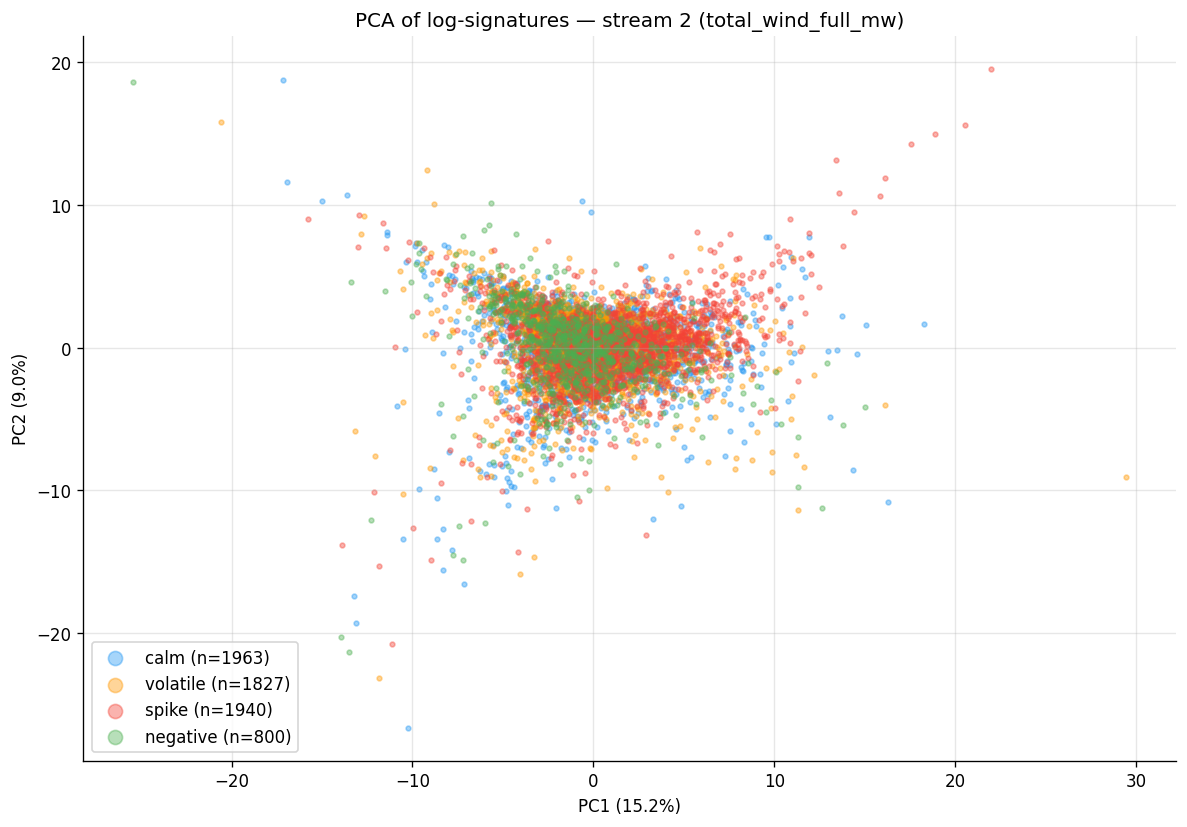

In [28]:
from sklearn.decomposition import PCA

ls_cols = [c for c in df_logsigs.columns if c.startswith("ls_")]
X = df_logsigs.select(ls_cols).to_numpy()
regimes_arr = df_logsigs["regime"].to_list()

X_mean = X.mean(axis=0)
X_std  = X.std(axis=0)
X_std[X_std < 1e-8] = 1.0
X_norm = (X - X_mean) / X_std

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_norm)
print(f"PCA explained variance: {pca.explained_variance_ratio_.sum()*100:.1f}% (first 2 components)")

colors = {"calm": "#2196F3", "volatile": "#FF9800", "spike": "#F44336", "negative": "#4CAF50"}
fig, ax = plt.subplots(figsize=(10, 7))
for regime, color in colors.items():
    mask = [r == regime for r in regimes_arr]
    if sum(mask) == 0: continue
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], c=color, s=8, alpha=0.4,
               label=f"{regime} (n={sum(mask)})")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
ax.set_title("PCA of log-signatures — stream 2 (total_wind_full_mw)")
ax.legend(markerscale=3)
plt.tight_layout()
plt.savefig(DATA_DIR / "03_s2_signature_pca.png", bbox_inches="tight")
plt.show()

### CELL 9 — Lévy area vs realised volatility
Examines the relationship (via scatter plot and correlation score) between the specific Lévy Area cross-term signature coordinate and realized volatility.

Correlation |Lévy area (ls_7)| vs realised vol: 0.1569


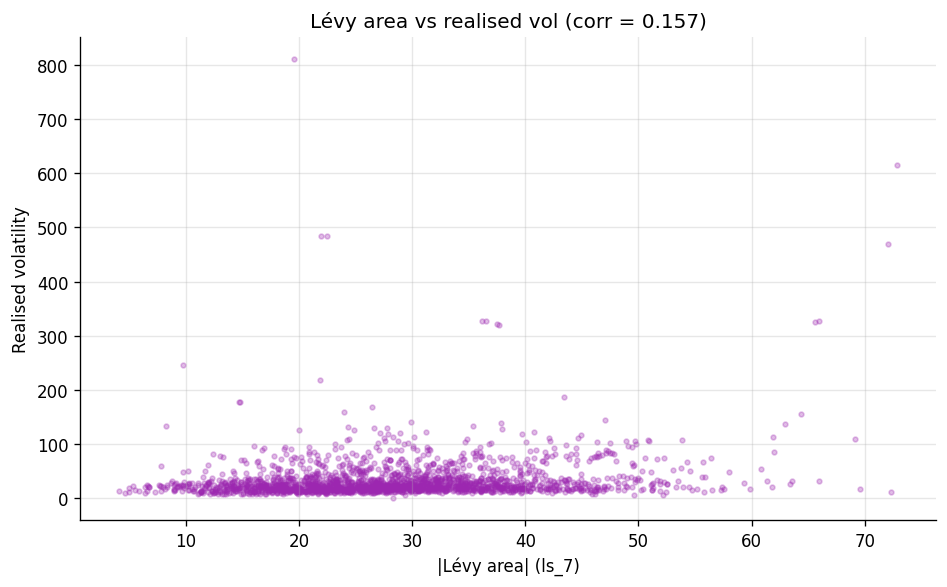

In [29]:
if f"ls_{LEVY_AREA_IDX}" in df_logsigs.columns:
    levy_area    = df_logsigs[f"ls_{LEVY_AREA_IDX}"].to_numpy()
    realised_vol = df_logsigs["realised_vol"].to_numpy()
    corr_levy = np.corrcoef(np.abs(levy_area), realised_vol)[0, 1]
    print(f"Correlation |Lévy area (ls_{LEVY_AREA_IDX})| vs realised vol: {corr_levy:.4f}")

    fig, ax = plt.subplots(figsize=(8, 5))
    sample = np.random.choice(len(levy_area), size=min(2000, len(levy_area)), replace=False)
    ax.scatter(np.abs(levy_area[sample]), realised_vol[sample], alpha=0.3, s=8, color="#9C27B0")
    ax.set_xlabel(f"|Lévy area| (ls_{LEVY_AREA_IDX})")
    ax.set_ylabel("Realised volatility")
    ax.set_title(f"Lévy area vs realised vol (corr = {corr_levy:.3f})")
    plt.tight_layout()
    plt.savefig(DATA_DIR / "03_s2_levy_area.png", bbox_inches="tight")
    plt.show()

### CELL 10 — Save outputs
Writes out the finalized features DataFrame (`logsigs_s2.parquet`) and normalisation variables (`norm_stats_s2.json`) to the data directory.

In [30]:
out_path = DATA_DIR / "logsigs_s2.parquet"
df_logsigs.write_parquet(out_path)
print(f"Saved: logsigs_s2.parquet")
print(f"  Shape: {df_logsigs.shape}")
print(f"  Size:  {out_path.stat().st_size / 1e6:.2f} MB")

norm_stats_s2 = {
    "price_mean":     float(np.nanmean(prices)),
    "price_std":      float(np.nanstd(prices)),
    "wind_mean":      float(np.nanmean(wind)),
    "wind_std":       float(np.nanstd(wind)),
    "wind_col":       WIND_COL,
    "logsig_dim":     logsig_dim,
    "path_dim":       PATH_DIM,
    "sig_depth":      SIG_DEPTH,
    "seg_length":     SEGMENT_LENGTH,
    "step_size":      STEP_SIZE,
    "levy_area_idx":  LEVY_AREA_IDX,
    "n_segments":     len(logsig_records),
}
with open(DATA_DIR / "norm_stats_s2.json", "w") as f:
    json.dump(norm_stats_s2, f, indent=2)
print("Saved: norm_stats_s2.json")

print(f"\nStream 2 files:")
for fp in sorted(DATA_DIR.glob("*_s2*")):
    print(f"  {fp.name}: {fp.stat().st_size/1e3:.1f} KB")

Saved: logsigs_s2.parquet
  Shape: (6530, 138)
  Size:  5.23 MB
Saved: norm_stats_s2.json

Stream 2 files:
  03_s2_levy_area.png: 70.6 KB
  03_s2_signature_pca.png: 165.7 KB
  feature_analysis_s2.json: 4.4 KB
  logsigs_s2.parquet: 5227.9 KB
  norm_stats_s2.json: 0.3 KB
  segments_s2.parquet: 1449.1 KB
